# Problem Statement 1
# Rectangular Plate: Steady-State Heat Conduction
A thin rectangular plate of width $a$ and height $b$ has three sides held at $0^\circ\mathrm{C}$ while the fourth (top) side is held at a uniform temperature $T_0$. There is no internal heat generation and the plate is thin enough that conduction may be treated as two-dimensional, so that the steady-state temperature field satisfies Laplace's equation
$$
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
=0,
\qquad
0 \le x \le a,
\qquad
0 \le y \le b.
$$

#### Boundary Conditions
$$
T(x,0)=0,
\qquad
T(0,y)=0,
\qquad
T(a,y)=0,
\qquad
T(x,b)=T_0.
$$

#### Data
$$
a=0.4\ \mathrm{m},
\qquad
b=0.2\ \mathrm{m},
\qquad
T_0=100^\circ\mathrm{C}.
$$

#### Analytical Solution
By separation of variables,
$$
T(x,y)
=
\frac{4T_0}{\pi}
\sum_{n=1,3,5,\ldots}^{\infty}
\frac{1}{n}
\sin\left(\frac{n\pi x}{a}\right)
\frac{
\sinh\left(\frac{n\pi y}{a}\right)
}{
\sinh\left(\frac{n\pi b}{a}\right)
}.
$$
Use enough terms to ensure the series has converged to at least **five significant figures** before using it as your benchmark.

---

**Fig. 1:** Rectangular plate with three sides at $0^\circ\mathrm{C}$ and the top side at $T_0$; inset shows the interior 5-point stencil at node $(i,j)$.

---

## Tasks
> #### Derive the standard **5-point finite-difference equation** at an interior node, and assemble the global linear system
$$
[A]\{T\}=\{b\}
$$
for a uniform grid with
$$
\Delta x = \Delta y = h.
$$
---
> #### Solve the system using a **direct method** (Gaussian elimination or LU decomposition). Record the **CPU time** and **memory used** as the grid is refined:
$$
h = 0.02,\; 0.01,\; 0.005\ \mathrm{m}.
$$
---
> #### Solve the same system using:
- Jacobi
- Gauss-Seidel
- SOR
For SOR, try at least three values of the relaxation factor $\omega$, including the theoretical optimum for a rectangular Dirichlet problem.
Record the **number of iterations** and **CPU time** for each method.
---
> #### Compare all solutions with the analytical series at the points
$$
\left(\frac{a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{b}{2}\right),
\qquad
\left(\frac{3a}{4},\frac{b}{2}\right),
\qquad
\left(\frac{a}{2},\frac{3b}{4}\right).
$$

Tabulate the **maximum absolute error** versus $h$ and confirm the expected accuracy of the 5-point scheme.
$$
O(h^2)
$$

---
> #### Summarize, in a short paragraph, how solution time scales with the number of unknowns N for the direct method versus each iterative method, and recommend a solver for this problem class
---
---
## *Numerical Methods Project Requirements*
#### 1. Discretization Derivation
Derive the finite-difference (or control-volume) discretization from first principles **before** writing any code.

#### 2. Analytical Validation
Wherever an analytical solution is given, validate your numerical solution against it at several interior points and report the **maximum absolute and percentage errors**, not just a visual comparison of plots.

#### 3. Linear System Solution
Solve the linear system $[A]\{T\} = \{b\}$ by:

- **(i) Direct method**: Gaussian elimination / LU decomposition, exploiting bandedness where possible.
- **(ii) Iterative methods**: Jacobi, Gauss–Seidel, and SOR, as specified in each problem.

For each method, report:
- Number of iterations
- Wall-clock time
- Memory footprint (as the grid is refined)

Then discuss which approach you would recommend and why.

> **Note**: Problem 3 instead uses a Picard/Newton iteration around a tridiagonal solve, and Problem 4 may be solved by any method consistent with its own tasks.

#### 4. Grid-Refinement (Convergence) Study
Perform a grid-refinement study for **every** problem. Use at least three grid sizes, with error plotted or tabulated against $\Delta x$, $\Delta r$, or $\Delta \theta$ as appropriate.

#### 5. Convergence Criteria and Parameters
State all of the following clearly:
- Convergence criteria (e.g., $\max |T^{p+1} - T^p| < 10^{-6}$)
- Initial guesses used
- Relaxation factors used (for SOR or other iterative methods)



## Import Libraries

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import sympy as sp
import os
import time as t

## Generate Problem Statement Schematic (Figure 1)

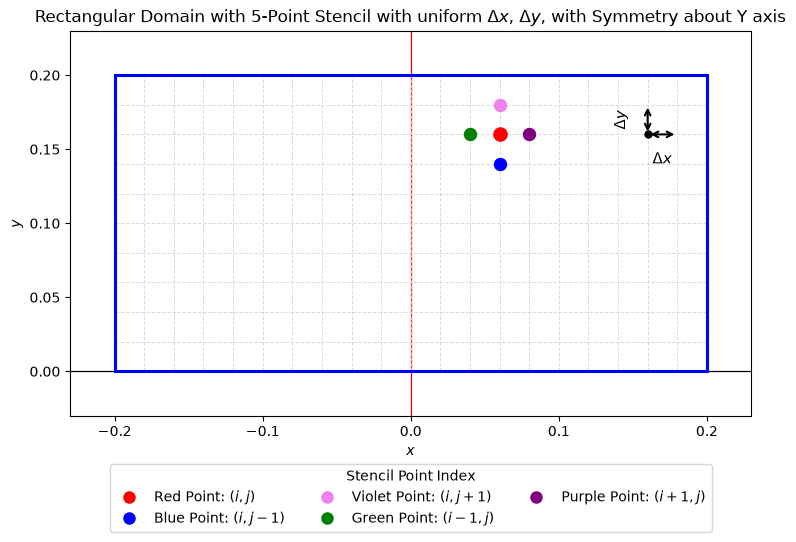

In [25]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------
length = 0.4
breadth = 0.2
#Placeholder for Graphical representation of the domain and the stencil points
dx = 0.02
dy = 0.02
y_shift = 0.1

#Problem has 1 Axis of Symmetry, so we can use half the domain for the simulation. The other half can be obtained by mirroring the results.
xmin, xmax = -length / 2, length / 2
ymin_ref, ymax_ref =0.0 , breadth
ymin, ymax = ymin_ref , ymax_ref

# ------------------------------------------------------------
# Mesh coordinates
# ------------------------------------------------------------
x_grid = np.arange(xmin, xmax + 1e-12, dx)
y_grid = np.arange(ymin_ref, ymax_ref + 1e-12, dy) + y_shift

# ------------------------------------------------------------
# Stencil points measured from the origin
# ------------------------------------------------------------
points = {
    "(i,j)": (3 * dx, 3 * dy + y_shift),     # red
    "(i,j-1)": (3 * dx, 2 * dy + y_shift),   # blue
    "(i,j+1)": (3 * dx, 4 * dy + y_shift),   # violet
    "(i-1,j)": (2 * dx, 3 * dy + y_shift),   # green
    "(i+1,j)": (4 * dx, 3 * dy + y_shift),   # purple
}

# ------------------------------------------------------------
# Location to move delta x and delta y arrows: grid point (8,3)
# ------------------------------------------------------------
base_x = 8 * dx
base_y = 3 * dy + y_shift

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Faint light-grey dashed mesh
for x in x_grid:
    ax.plot([x, x], [ymin , ymax], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

for y in y_grid:
    ax.plot([xmin, xmax], [y - y_shift, y - y_shift], linestyle="--", linewidth=0.7, color="lightgrey", alpha=0.8, zorder=1)

# Rectangle boundary in LaTeX blue
ax.add_patch(Rectangle((xmin, ymin), length, breadth, fill=False, edgecolor="#0000FF", linewidth=2.2, zorder=2))

# Cartesian axes through origin
ax.axhline(0, color="black", linewidth=0.9, zorder=0)
ax.axvline(0, color="Red", linewidth=0.9, zorder=0)

# ------------------------------------------------------------
# Stencil points
# ------------------------------------------------------------
ax.scatter(*points["(i,j)"], s=90, color="red", zorder=5)
ax.scatter(*points["(i,j-1)"], s=75, color="#0000FF", zorder=5)
ax.scatter(*points["(i,j+1)"], s=75, color="violet", zorder=5)
ax.scatter(*points["(i-1,j)"], s=75, color="green", zorder=5)
ax.scatter(*points["(i+1,j)"], s=75, color="purple", zorder=5)

# Mark the reference location (8,3)
ax.scatter(base_x, base_y, s=25, color="black", zorder=6)

# ------------------------------------------------------------
# Move delta x and delta y arrows to grid point (8,3)
# ------------------------------------------------------------
ax.annotate("", xy=(base_x + dx, base_y), xytext=(base_x, base_y), arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.annotate("", xy=(base_x, base_y + dy), xytext=(base_x, base_y), arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5), zorder=6)
ax.text(base_x + dx / 2, base_y - 0.012, r"$\Delta x$", ha="center", va="top", fontsize=11)
ax.text(base_x - 0.012, base_y + dy / 2, r"$\Delta y$", ha="right", va="center", rotation=90, fontsize=11)

# ------------------------------------------------------------
# Index / legend for stencil-point colors
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='red', markeredgecolor='red', markersize=8, label=r"Red Point: $(i,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#0000FF', markeredgecolor='#0000FF', markersize=8, label=r"Blue Point: $(i,j-1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='violet', markeredgecolor='violet', markersize=8, label=r"Violet Point: $(i,j+1)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='green', markeredgecolor='green', markersize=8, label=r"Green Point: $(i-1,j)$"),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='purple', markeredgecolor='purple', markersize=8, label=r"Purple Point: $(i+1,j)$"),
]

ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=True, fontsize=10, title="Stencil Point Index")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin - 0.03, xmax + 0.03)
ax.set_ylim(ymin_ref - 0.03, ymax_ref + 0.03)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Rectangular Domain with 5-Point Stencil with uniform $\Delta x$, $\Delta y$, with Symmetry about Y axis")

plt.show()

# Task (A)
> Derive the standard **5-point finite-difference equation** at an interior node, and assemble the global linear system

![](../../Images/Problem1/DerivationPage1.png)

![](../../Images/Problem1/DerivationPage2.png)

For the reduced half-domain,
$$
0 \le x \le \frac{a}{2},
\qquad
0 \le y \le b,
$$
with a uniform grid spacing
$$
\Delta x = \Delta y = h,
$$
the number of grid points in the $x$-direction is
$$
\boxed{
n_x = \frac{a/2}{h} + 1
= \frac{a}{2h}+1
}
$$
and the number of grid points in the $y$-direction is
$$
\boxed{
n_y = \frac{b}{h}+1
}
$$
where $n_x$ and $n_y$ include the boundary points. Therefore,
$$
\boxed{
n_x = \frac{a}{2h}+1,
\qquad
n_y = \frac{b}{h}+1
}
$$
given that
$$
\frac{a}{2h}
\qquad \text{and} \qquad
\frac{b}{h}
$$
are integers.


---
![](../../Images/Problem1/DerivationPage3.png)

#### Matrix is given as:


Define
$$
N_x=n_x-1, 
$$
This is because the last column of the rectangular grid will have no finite difference form as it is a dirichlet boundary condition (i=nx)
$$
N_y=n_y-2, 
$$
This is because the top and bottom row of the rectangular grid will have no finite difference form as it is a dirichlet boundary condition (j = 0 and j = ny)

so that the total number of unknown temperatures is

$$
N=N_xN_y=(n_x-1)(n_y-2).
$$

The unknown vector is ordered row-by-row as

$$
\mathbf{x}
=
\begin{bmatrix}
T_{0,1} \\
T_{1,1} \\
T_{2,1} \\
\vdots \\
T_{N_x-1,1} \\
T_{0,2} \\
T_{1,2} \\
\vdots \\
T_{N_x-1,N_y}
\end{bmatrix}.
$$

For a uniform square mesh, $\Delta x=\Delta y=h$, the system is

$$
\boxed{\mathbf{A}\mathbf{x}=\mathbf{b}}
$$

where

> ### For $\Delta h = 0.02$ , and applied symmetry condition, we have
##### Discretized Linear System

The finite-difference equations can be written in matrix form as

$$
\mathbf{A}\mathbf{x}=\mathbf{b}
$$

##### System Matrix $\mathbf{A}$

$$
\mathbf{A}=
\left[
\begin{array}{rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
-4 & 2 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\

1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -4 & 2 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -4 & 2 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -4 & 2 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & -4
\end{array}
\right]
$$

### Unknown Temperature Vector and Right-Hand-Side Vector

$$
\mathbf{x}=
\begin{bmatrix}
T_{0}\\
T_{1}\\
T_{2}\\
T_{3}\\
T_{4}\\
T_{5}\\
T_{6}\\
T_{7}\\
T_{8}\\
T_{9}\\
T_{10}\\
T_{11}\\
T_{12}\\
T_{13}\\
T_{14}\\
T_{15}\\
T_{16}\\
T_{17}\\
T_{18}\\
T_{19}\\
T_{20}\\
T_{21}\\
T_{22}\\
T_{23}\\
T_{24}\\
T_{25}\\
T_{26}\\
T_{27}\\
T_{28}\\
T_{29}\\
T_{30}\\
T_{31}\\
T_{32}\\
T_{33}\\
T_{34}\\
T_{35}\\
T_{36}\\
T_{37}\\
T_{38}\\
T_{39}
\end{bmatrix}
\qquad
\mathbf{b}=
\begin{bmatrix}
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
0\\
-100\\
-100\\
-100\\
-100\\
-100\\
-100\\
-100\\
-100\\
-100\\
-100
\end{bmatrix}
$$


> **NOTE: Here the first row of the matrix is different as it incorporates the symmetry boundary condition which is a result of the domain halving to reduce number of computations.**

#### Prescribed Boundary Conditions

**Bottom boundary:**

$$
T_{i,0}=0,
\qquad
i=0,1,\ldots,n_x-1
$$

**Right boundary:**

$$
T_{n_x-1,j}=0,
\qquad
j=0,1,\ldots,n_y-1
$$

**Top boundary:**

$$
T_{i,n_y-1}=T_0=100^\circ\mathrm{C},
\qquad
i=0,1,\ldots,n_x-1
$$

The left boundary is the symmetry boundary and is therefore not Dirichlet:

$$
\left.
\frac{\partial T}{\partial x}
\right|_{i=0}
=0.
$$

with

$$
T_0=100^\circ\mathrm C.
$$

Thus,

$$
\boxed{
\mathbf A_{\,N\times N}
\mathbf x_{\,N\times1}
=
\mathbf b_{\,N\times1},
\qquad
N=(n_x-1)(n_y-2)
}
$$


### Variable and Mesh Setup

Following section allows to edit with the mesh grid and boundary conditions to solve for various cases for a similar domain.

In [26]:
a = 0.4/2 # Length of the rectangular domain
b = 0.2/2 # Width of the rectangular domain
TNorthWall = 100 # Temperature at the North wall
TSouthWall = 0 # Temperature at the South wall
TEastWall = 0 # Temperature at the East wall
TWestWall = 0 # Temperature at the West wall // Not used as we are exploiting symmetry.


h = 0.02
nX = int(a/h) + 1 # Number of grid points in x direction
nY = int(b/h) + 1 # Number of grid points in y direction

i = range(0, nX-1) # x index for interior points
j = range(1, nY-2) # y index for interior points

N = (nX-1)*(nY-2) # Total number of unknowns in the domain (excluding boundary points)


# Defined a meshGrid dictionary to store the mapping of grid point indices to their corresponding (row, column) coordinates in the mesh. The loop iterates over the interior points of the grid (excluding boundary points) and populates the meshGrid dictionary with the appropriate mappings.
linaearizedMeshGrid =  {}
meshGrid = np.zeros((nY-2,nX-1), dtype=float)
unifiedIndexMap = []

for rowId in range(nY - 2):
    for columnId in range(0, nX - 1):
        unifiedIndex = columnId + (nX - 1)*rowId
        unifiedIndexMap.append(unifiedIndex)
        if rowId == 0:
            linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "SouthEnd"]
        elif rowId == nY - 3:
            linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "NorthEnd"]
        elif columnId == 0:
            linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "WestEnd"]
        elif columnId == nX - 2:
            linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "EastEnd"]
        else:
            linaearizedMeshGrid[unifiedIndex] = [meshGrid[rowId][columnId], "Interior"]

        if unifiedIndex == 0:
            linaearizedMeshGrid[unifiedIndex][1] = "SymmetricSouthWestCorner"
        if unifiedIndex == nX - 2:
            linaearizedMeshGrid[unifiedIndex][1] = "DirichletSouthEastCorner"
        if unifiedIndex == (nX - 1)*(nY - 2) - (nX - 1):
            linaearizedMeshGrid[unifiedIndex][1] = "SymmetricNorthWestCorner"
        if unifiedIndex == (nX - 1)*(nY - 2) - 1:
            linaearizedMeshGrid[unifiedIndex][1] = "DirichletNorthEastCorner"

print("X indices:", list(range(0, nX-1)))
print("Y indices:", list(range(1, nY-2)))
print("Linearized Mesh Grid:", linaearizedMeshGrid)

X indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Y indices: [1, 2, 3]
Linearized Mesh Grid: {0: [np.float64(0.0), 'SymmetricSouthWestCorner'], 1: [np.float64(0.0), 'SouthEnd'], 2: [np.float64(0.0), 'SouthEnd'], 3: [np.float64(0.0), 'SouthEnd'], 4: [np.float64(0.0), 'SouthEnd'], 5: [np.float64(0.0), 'SouthEnd'], 6: [np.float64(0.0), 'SouthEnd'], 7: [np.float64(0.0), 'SouthEnd'], 8: [np.float64(0.0), 'SouthEnd'], 9: [np.float64(0.0), 'DirichletSouthEastCorner'], 10: [np.float64(0.0), 'WestEnd'], 11: [np.float64(0.0), 'Interior'], 12: [np.float64(0.0), 'Interior'], 13: [np.float64(0.0), 'Interior'], 14: [np.float64(0.0), 'Interior'], 15: [np.float64(0.0), 'Interior'], 16: [np.float64(0.0), 'Interior'], 17: [np.float64(0.0), 'Interior'], 18: [np.float64(0.0), 'Interior'], 19: [np.float64(0.0), 'EastEnd'], 20: [np.float64(0.0), 'WestEnd'], 21: [np.float64(0.0), 'Interior'], 22: [np.float64(0.0), 'Interior'], 23: [np.float64(0.0), 'Interior'], 24: [np.float64(0.0), 'Interior'], 25: [np.float64(0.0)

### Mesh Validation

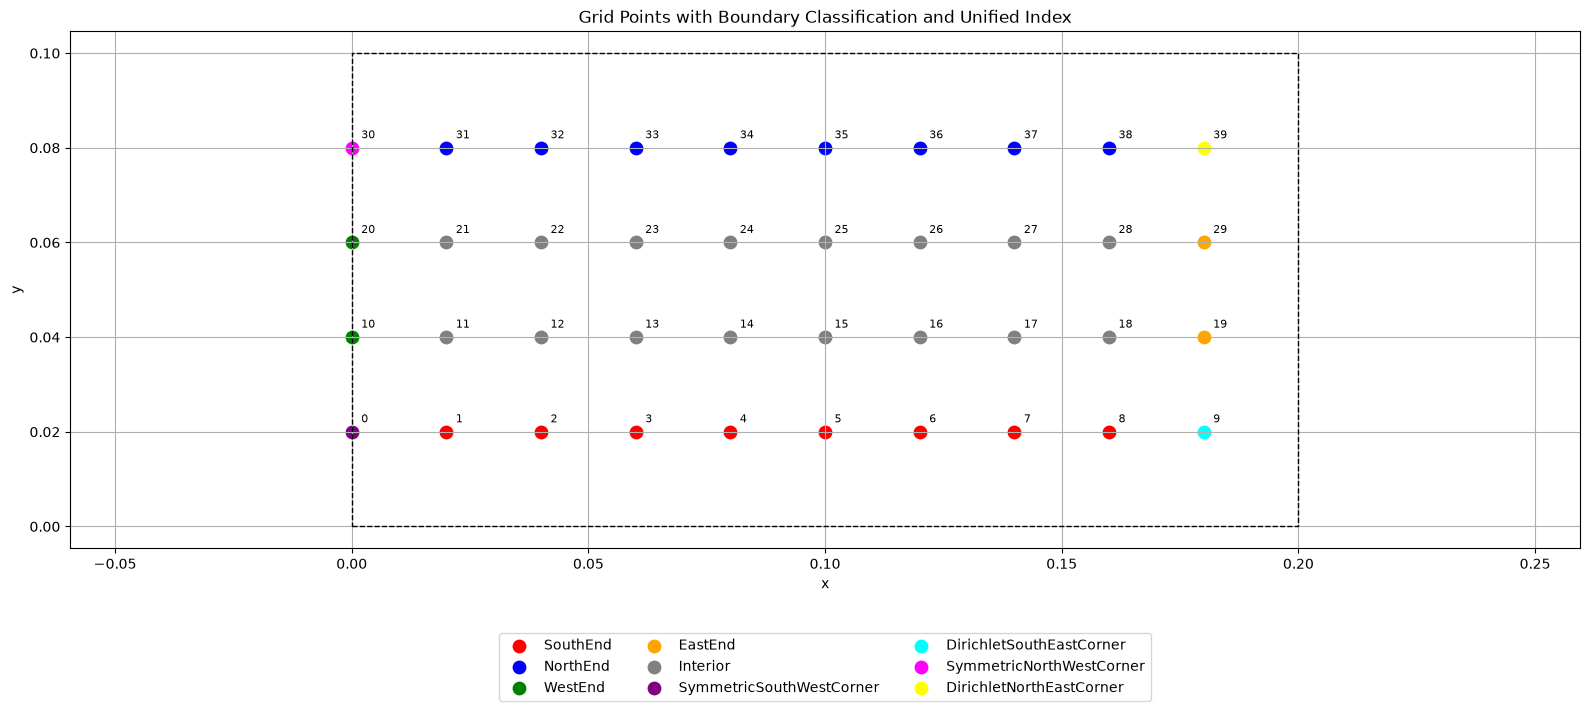

In [27]:
# Physical coordinates
x_coords = np.linspace(0, a-h, nX-1)   # columns: 0 to nX-2
y_coords = np.linspace(h, b-h, nY-2)   # rows:    1 to nY-2 in physical space

# ------------------------------------------------------------
# Colors for each node type
# ------------------------------------------------------------
#Set colors for mesh node type:
colors = {
    "SouthEnd": "red",
    "NorthEnd": "blue",
    "WestEnd": "green",
    "EastEnd": "orange",
    "Interior": "gray",
    "SymmetricSouthWestCorner": "purple",
    "DirichletSouthEastCorner": "cyan",
    "SymmetricNorthWestCorner": "magenta",
    "DirichletNorthEastCorner": "yellow"
}
# ------------------------------------------------------------
# Plot the grid points
# ------------------------------------------------------------
plt.figure(figsize=(16, 8))

for rowId in range(nY - 2):
    for columnId in range(0, nX - 1):
        unifiedIndex = columnId + (nX - 1)*rowId
        nodeType = linaearizedMeshGrid[unifiedIndex][1]
        x = x_coords[columnId]
        y = y_coords[rowId]
        plt.scatter(x, y, color=colors[nodeType], s=80)
        plt.text(x + 0.002, y + 0.002, str(unifiedIndex), fontsize=8)

# Domain outline
plt.plot([0, a, a, 0, 0], [0, 0, b, b, 0], 'k--', linewidth=1)

# Legend
for label, color in colors.items():
    plt.scatter([], [], color=color, s=80, label=label)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Grid Points with Boundary Classification and Unified Index")
plt.axis("equal")
plt.grid(True)

# Put legend below the plot
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=10,
    frameon=True
)

# Add space at bottom for legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

### Setting Up System Matrix

Following section now uses the carefully setup linearMesgGrid, stored as a dictionary, for ease of naming and indexing and generates the Matrix Equations which will give us the solution to our problem at hand.

In [28]:
#Data Structures for Finite Difference Stencil
class StencilPointIds:
    def __init__(self, point, N, S, E, W):
        self.point = point
        self.N = N
        self.S = S
        self.E = E
        self.W = W

temperatureVector = np.zeros((N, 1), dtype=float)
systemMatrix = np.zeros((N, N), dtype=float)

def ComputeNSEWPointIds(meshPointId):
    # Compute the North, South, East, and West point IDs based on the current meshPointId
    northId = meshPointId + (nX - 1) if (meshPointId + (nX - 1)) < N else None
    southId = meshPointId - (nX - 1) if (meshPointId - (nX - 1)) >= 0 else None
    eastId = meshPointId + 1 if (meshPointId + 1) % (nX - 1) != 0 else None
    westId = meshPointId - 1 if meshPointId % (nX - 1) != 0 else None

    return StencilPointIds(meshPointId, northId, southId, eastId, westId)

def GenerateSymmetricBoundaryCornerEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    testVector = np.zeros((1, N), dtype=float)
    if(linaearizedMeshGrid[meshPointId][1] == "SymmetricSouthWestCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = -TSouthWall;
    elif linaearizedMeshGrid[meshPointId][1] == "SymmetricNorthWestCorner":
        systemMatrix[meshPointId,dependencyMap.point] = -4.0;
        systemMatrix[meshPointId,dependencyMap.S] = 1.0;
        systemMatrix[meshPointId,dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = -TNorthWall;
    elif linaearizedMeshGrid[meshPointId][1] == "WestEnd":
        systemMatrix[meshPointId,dependencyMap.point] = -4.0;
        systemMatrix[meshPointId,dependencyMap.N] = 1.0;
        systemMatrix[meshPointId,dependencyMap.S] = 1.0;
        systemMatrix[meshPointId,dependencyMap.E] = 2.0;
        temperatureVector[dependencyMap.point] = 0.0;

def GenerateDirichletBoundaryCornerEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    testVector = np.zeros((1, N), dtype=float)
    if (linaearizedMeshGrid[meshPointId][1] == "NorthEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        temperatureVector[dependencyMap.point] = -TNorthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "SouthEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        temperatureVector[dependencyMap.point] = -TSouthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "EastEnd"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -TEastWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "DirichletSouthEastCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -TEastWall - TSouthWall;
    elif (linaearizedMeshGrid[meshPointId][1] == "DirichletNorthEastCorner"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = -TEastWall - TNorthWall;

def GenerateInternalNodeEquations(meshPointId):
    dependencyMap = ComputeNSEWPointIds(meshPointId)
    testVector = np.zeros((1, N), dtype=float)
    if (linaearizedMeshGrid[meshPointId][1] == "Interior"):
        systemMatrix[meshPointId, dependencyMap.point] = -4.0;
        systemMatrix[meshPointId, dependencyMap.N] = 1.0;
        systemMatrix[meshPointId, dependencyMap.S] = 1.0;
        systemMatrix[meshPointId, dependencyMap.E] = 1.0;
        systemMatrix[meshPointId, dependencyMap.W] = 1.0;
        temperatureVector[dependencyMap.point] = 0.0;

for(meshPointId) in range(N):
    if linaearizedMeshGrid[meshPointId][1] == "SymmetricSouthWestCorner" or linaearizedMeshGrid[meshPointId][1] == "SymmetricNorthWestCorner" or linaearizedMeshGrid[meshPointId][1] == "WestEnd":
        GenerateSymmetricBoundaryCornerEquations(meshPointId)
    elif linaearizedMeshGrid[meshPointId][1] == "NorthEnd" or linaearizedMeshGrid[meshPointId][1] == "SouthEnd" or linaearizedMeshGrid[meshPointId][1] == "EastEnd" or linaearizedMeshGrid[meshPointId][1] == "DirichletSouthEastCorner" or linaearizedMeshGrid[meshPointId][1] == "DirichletNorthEastCorner":
        GenerateDirichletBoundaryCornerEquations(meshPointId)
    elif linaearizedMeshGrid[meshPointId][1] == "Interior":
        GenerateInternalNodeEquations(meshPointId)

print("System Matris is Generated. The shape of the system matrix is:", systemMatrix.shape)
print("Temperature Vector is Generated. The shape of the temperature vector is:", temperatureVector.shape)


System Matris is Generated. The shape of the system matrix is: (40, 40)
Temperature Vector is Generated. The shape of the temperature vector is: (40, 1)
